# Training a classifier

This is it.  You have seen how to define neural networks, compute loss and make updates to weights of the network.

Now you might be thinking, what about data?

Generally, when you have to deal with image, text, audio, or video you can use standard python packages that load data into a numpy array.  Then you can convert this array into a `torch.*Tensor`.

* For images, packages such as Pillow and OpenCV are useful
* For audio, packages such as scipy and librosa
* For text, either raw Python or Cython based loadng, or NLTK and SpaCy are useful

Specifically for vision, we have created a package called `torchvision`, that has data loaders for common datasets such as Imagenet, CIFAR10, MNIST etc. and data transformers for images, viz., `torchvision.datasets` and `torch.utils.data.DataLoader`.

This mitigates the need to write boilerplate code.

For this tutorial, we will use the CIFAR10 dataset.  It has the classes: 'airplane', 'automobile', 'bird', 'cat', 'deer', 'dog', 'frog', 'horse', 'ship', 'truck'.  The images in CIFAR10 are of size 3x32x32, i.e. 3-channel color images of 32x32 pixels in size.

## Training an image classifier

We will do the following steps in order:

1. Load and normalizing the CIFAR10 training and test datasets using `torchvision`
2. Define a CNN
3. Define a loss function
4. Train the network on the training data
5. Test the network on the test data




## 1. Loading and normalizing CIFAR10

Using `torchvision` it's extremely easy to load CIFAR10.


In [1]:
import torch
import torchvision
import torchvision.transforms as transforms


The outut of torchvision datasets are PILImage images of range `[0. 1]`.  We transform them to Tensors of normalized range `[-1, 1]`.

**Note: if running on Windows and you get a `BrokenPipeError`, try setting the num_worker of `torch.utils.data.DataLoader()` to 0.**

In [2]:
transform = transforms.Compose(
    [transforms.ToTensor(),
     transforms.Normalize(
        (0.5, 0.5, 0.5), (0.5, 0.5, 0.5))]
)

trainset = torchvision.datasets.CIFAR10(
    root='./data', train=True,
    download=True, transform=transform
)

trainloader = torch.utils.data.DataLoader(
    trainset, batch_size=4,
    shuffle=True, num_workers=2
)

testset = torchvision.datasets.CIFAR10(
    root='./data', train=False,
    download=True, transform=transform
)

testloader = torch.utils.data.DataLoader(
    testset, batch_size=4,
    shuffle=False, num_workers=2
)

classes = (
    'plane', 'car', 'bird', 'cat', 'deer', 'dog',
    'frog', 'horse', 'ship', 'truck'
)


Files already downloaded and verified
Files already downloaded and verified


Let us show some of the training images for fun:

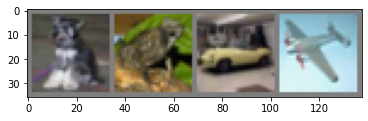

  dog  frog   car plane


In [3]:
import matplotlib.pyplot as plt
import numpy as np

# functions to show an image

def imshow(img):
    img = img / 2 + 0.5 # Denormalize
    npimg = img.numpy()
    plt.imshow(np.transpose(npimg, (1, 2, 0)))
    plt.show()

# get some random training images
dataiter = iter(trainloader)
images, labels = dataiter.next()

# show images
imshow(torchvision.utils.make_grid(images))

# print labels
print(' '.join(
    '%5s' % classes[labels[j]] for j in range(4)))

## 2. Define a CNN

Copy the neural network from the Neural Networks section before and modify it to take 3-channel images (instead of 1-channel images as it was defined).


In [4]:
import torch.nn as nn
import torch.nn.functional as F

class Net(nn.Module):
    def __init__(self):
        super(Net, self).__init__()
        self.conv1 = nn.Conv2d(3, 6, 5)
        self.pool = nn.MaxPool2d(2, 2)
        self.conv2 = nn.Conv2d(6, 16, 5)
        self.fc1 = nn.Linear(16 * 5 * 5, 120)
        self.fc2 = nn.Linear(120, 84)
        self.fc3 = nn.Linear(84, 10)

    def forward(self, x):
        x = self.pool(F.relu(self.conv1(x)))
        x = self.pool(F.relu(self.conv2(x)))
        x = x.view(-1, 16 * 5 * 5)
        x = F.relu(self.fc1(x))
        x = F.relu(self.fc2(x))
        x = self.fc3(x)
        return x

net = Net()


## 3. Define a Loss function and optimizer

Let's use a Classification Cross-Entropy loss and SGD with momentum.

In [5]:
import torch.optim as optim

criterion = nn.CrossEntropyLoss()
optimizer = optim.SGD(
    net.parameters(), lr=0.001, momentum=0.9)


## 4. Train the network

This is when things start to get interesting.  We simply have to loop over our data iterator, and feed the inputs to the network and optimize.

In [6]:
use_gpu = True

if use_gpu:
    device = torch.device(
        "cuda:0" if torch.cuda.is_available() else "cpu")
    net.to(device)

print(device)


for epoch in range(2):

    running_loss = 0.0

    for i, data in enumerate(trainloader, 0):

        # get the inputs; data is a list of
        # [inputs, labels]
        if use_gpu:
            inputs, labels = \
                data[0].to(device), data[1].to(device)
        else:
            inputs, labels = data

        # zero the parameter gradients
        optimizer.zero_grad()

        # forward + backward + optimizer
        outputs = net(inputs)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        # print statistics
        running_loss += loss.item()

        if i % 2000 == 1999:
            print(
                '[%d, %5d] loss: %.3f' %
                (epoch + 1, i + 1,
                 running_loss / 2000))
            running_loss = 0.0

print('Finished Training')


cuda:0
[1,  2000] loss: 2.238
[1,  4000] loss: 1.915
[1,  6000] loss: 1.717
[1,  8000] loss: 1.615
[1, 10000] loss: 1.554
[1, 12000] loss: 1.486
[2,  2000] loss: 1.452
[2,  4000] loss: 1.394
[2,  6000] loss: 1.371
[2,  8000] loss: 1.356
[2, 10000] loss: 1.331
[2, 12000] loss: 1.302
Finished Training


In [7]:
# Save the trained model
PATH = './cifar_net.pth'
torch.save(net.state_dict(), PATH)

## 5. Test the network on the test data

We have trained the network for 2 passes over the training dataset.  But we need to check if the network has learned anything at all.

We will check this by predicting the class label that the neural entwork outputs, and checking it against the ground-truth.  If the prediction is correct, we add the sample to the list of correct predictions.

Okay, first step.  Let us display an image from the test set to get familiar.

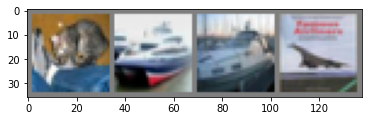

GroundTruth:    cat  ship  ship plane


In [8]:
dataiter = iter(testloader)

images, labels = dataiter.next()

# print images
imshow(torchvision.utils.make_grid(images))
print(
    'GroundTruth: ',
    ' '.join('%5s' % classes[labels[j]] for j in range(4)))

Next, let's load back in out saved model (note: saving and reoading the model wasn't necesary here, we only did it to illustrate how to do so):

In [9]:
net = Net()
net.load_state_dict(torch.load(PATH))

if use_gpu:
    net.to(device)
    images = images.to(device)
    labels = labels.to(device)


Okay, now let us see what the neural network thinks these examples above are:


In [10]:
outputs = net(images)

The outputs are energies for the 10 classes.  The higher the energy for a class, the more the network think that the image is of the particular class.  So, let's get the index of the highest energy:


In [11]:
_, predicted = torch.max(outputs, 1)

print(
    'Predicted: ',
    ' '.join('%5s' % classes[predicted[j]]
        for j in range(4))
)

Predicted:    cat  ship   car plane


The results seem pretty good.

Let us look at how the network performs on the whole dataset.

In [12]:
correct = 0
total = 0

with torch.no_grad():
    for data in testloader:

        if use_gpu:
            images, labels = \
                data[0].to(device), data[1].to(device)
        else:
            images, labels = data

        outputs = net(images)
        _, predicted = torch.max(outputs.data, 1)
        total += labels.size(0)
        correct += (predicted == labels).sum().item()

print(
    'Accuracy: %d %%' %
    (100 * correct / total))

Accuracy: 55 %


That looks way better than chance, which is 10% accuracy (randomy picking a class out of 10 classes).  Seems like the network learned something.

Which classes performed well?




In [13]:
class_correct = list(0 for i in range(10))
class_total = list(0 for i in range(10))

with torch.no_grad():
    for data in testloader:

        if use_gpu:
            images, labels = \
                data[0].to(device), data[1].to(device)
        else:
            images, labels = data

        outputs = net(images)
        _, predicted = torch.max(outputs, 1)
        c = (predicted == labels).squeeze()
        
        for i in range(4):
            label = labels[i]
            class_correct[label] += c[i].item()
            class_total[label] += 1

for i in range(10):
    print(
        'Accuracy of %5s : %2d %%' % (
            classes[i],
            100 * class_correct[i] / \
            class_total[i]
        ))

Accuracy of plane : 59 %
Accuracy of   car : 67 %
Accuracy of  bird : 46 %
Accuracy of   cat : 21 %
Accuracy of  deer : 32 %
Accuracy of   dog : 40 %
Accuracy of  frog : 66 %
Accuracy of horse : 71 %
Accuracy of  ship : 76 %
Accuracy of truck : 68 %


## Train on GPU

Just like how you transfer a Tensor onto the GPU, you transfer the neural net onto the GPU.

Let's first define our device as the first visible cuda device if we have CUDA available:


In [14]:
device = torch.device(
    "cuda:0" if torch.cuda.is_available() else "cpu")

print(device)

cuda:0


These methods will recursivel go over all modues and convert their parameters and buffers to CUDA tensors:

In [15]:
net.to(device)

Net(
  (conv1): Conv2d(3, 6, kernel_size=(5, 5), stride=(1, 1))
  (pool): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (conv2): Conv2d(6, 16, kernel_size=(5, 5), stride=(1, 1))
  (fc1): Linear(in_features=400, out_features=120, bias=True)
  (fc2): Linear(in_features=120, out_features=84, bias=True)
  (fc3): Linear(in_features=84, out_features=10, bias=True)
)

In [16]:
inputs, labels = \
    data[0].to(device), data[1].to(device)